# Athlete Nutrition ML Notebook 



 # 1. INTRODUCTION

In this notebook, I build a machine learning pipeline to predict daily calorie needs for athletes based on features such as weight, height, age, sport type, intensity, and goal.

The workflow includes:

1. INTRODUCTION

2. Data loading. 

3. Data cleaning

4. Exploratory Data Analysis (EDA)

5. Data preprocessing

6. Train a neural network using PyTorch Lightning

7. Use early stopping to prevent overfitting


PyTorch Lightning is used to structure the training process in a clean and scalable way.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings("ignore")

pl.seed_everything(42)

Seed set to 42


42

# 2. LOAD DATA

In this step, I load the dataset from an Excel file and inspect its structure to understand the available features and data types.

In [194]:
df = pd.read_excel("../dataset/athlete_nutrition_dataset.xlsx")
df.head(10)

,Sport,Weight,Height,Age,Goal,PreviousDay2_Intensity,PreviousDay2_Duration,PreviousDay1_Intensity,PreviousDay1_Duration,CurrentDay_Intensity,CurrentDay_Duration,Calories
0,bodybuilding,72,160,26,muscle_gain,high,33,medium,92,medium,100,3501
1,mma,84,160,20,fat_loss,low,111,low,97,medium,57,3040
2,bodybuilding,92,198,28,muscle_gain,high,94,low,70,high,49,3923
3,running,78,195,31,fat_loss,high,56,high,115,medium,100,3139
4,mma,77,171,39,endurance_performance,medium,67,medium,34,low,111,3451
5,running,63,163,29,endurance_performance,medium,79,low,87,low,45,2724
6,football,83,198,24,maintenance,high,75,medium,62,medium,101,3341
7,football,95,168,35,fat_loss,low,118,high,44,low,35,2876
8,mma,104,199,39,muscle_gain,high,96,low,41,medium,111,4602
9,football,98,191,18,muscle_gain,medium,91,medium,42,low,113,3977


In [195]:
# Dataset info
df.info()

# Shape of dataset
print("Dataset shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Sport                   1500 non-null   str  
 1   Weight                  1500 non-null   int64
 2   Height                  1500 non-null   int64
 3   Age                     1500 non-null   int64
 4   Goal                    1500 non-null   str  
 5   PreviousDay2_Intensity  1500 non-null   str  
 6   PreviousDay2_Duration   1500 non-null   int64
 7   PreviousDay1_Intensity  1500 non-null   str  
 8   PreviousDay1_Duration   1500 non-null   int64
 9   CurrentDay_Intensity    1500 non-null   str  
 10  CurrentDay_Duration     1500 non-null   int64
 11  Calories                1500 non-null   int64
dtypes: int64(7), str(5)
memory usage: 140.8 KB
Dataset shape: (1500, 12)


The dataset contains the following columns:

Dataset shape: (1500, 12) → 1500 athletes, 12 columns.

Sport

Weight

Height

Age

Goal

PreviousDay2_Intensity

PreviousDay2_Duration   

PreviousDay1_Intensity  

PreviousDay1_Duration  

CurrentDay_Intensity   

CurrentDay_Duration 

Calories (target variable)

# 3. DATA EXPLORATION (EDA)

3.1 DATA QUALITY CHECK

Here I check for missing values and duplicates.

In [196]:
df.describe()

,Weight,Height,Age,PreviousDay2_Duration,PreviousDay1_Duration,CurrentDay_Duration,Calories
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,82.196000,179.498667,29.062000,75.151333,75.421333,76.708000,3360.875333
std,15.938515,11.784223,6.637434,25.794470,26.612703,26.049987,566.291769
min,55.000000,160.000000,18.000000,30.000000,30.000000,30.000000,1760.000000
25%,68.750000,169.000000,23.000000,53.000000,52.000000,54.000000,2954.250000
50%,82.000000,179.000000,29.000000,75.000000,76.000000,78.000000,3348.500000
75%,96.000000,190.000000,35.000000,97.000000,98.000000,99.000000,3789.000000
max,110.000000,200.000000,40.000000,120.000000,120.000000,120.000000,4916.000000


In [197]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

Missing values:
 Sport                     0
Weight                    0
Height                    0
Age                       0
Goal                      0
PreviousDay2_Intensity    0
PreviousDay2_Duration     0
PreviousDay1_Intensity    0
PreviousDay1_Duration     0
CurrentDay_Intensity      0
CurrentDay_Duration       0
Calories                  0
dtype: int64
Duplicates: 0


Missing values: 0 in every column.


In [198]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


Duplicates: 0 duplicate rows.

3.2 CLASS DISTRIBUTION (CATEGORICAL FEATURES)

Here I analyze how data is distributed across categories.

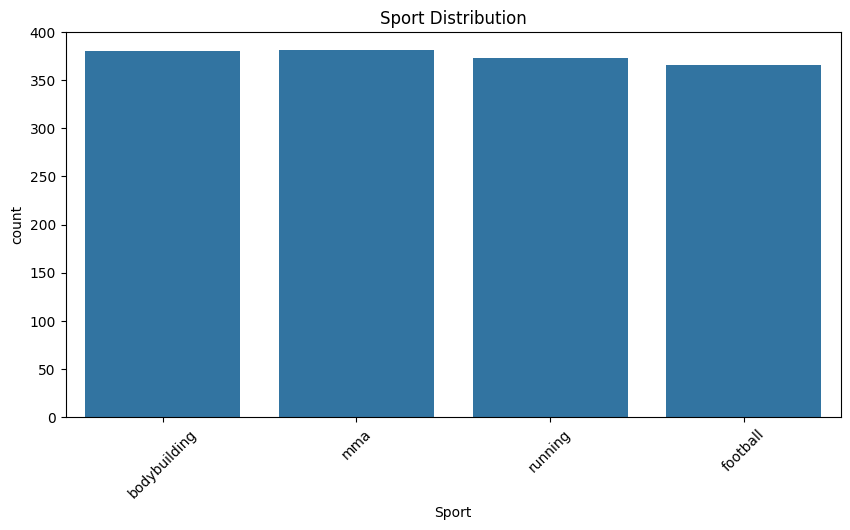

In [199]:
plt.figure(figsize=(10,5))
sns.countplot(x="Sport", data=df)
plt.xticks(rotation=45)
plt.title("Sport Distribution")
plt.show()

Sport distribution: Roughly equal counts for running, football, MMA, bodybuilding (~375 each).

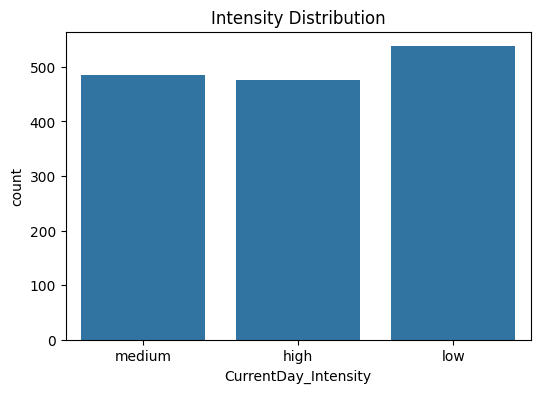

In [200]:
plt.figure(figsize=(6,4))
sns.countplot(x="CurrentDay_Intensity", data=df)
plt.title("Intensity Distribution")
plt.show()

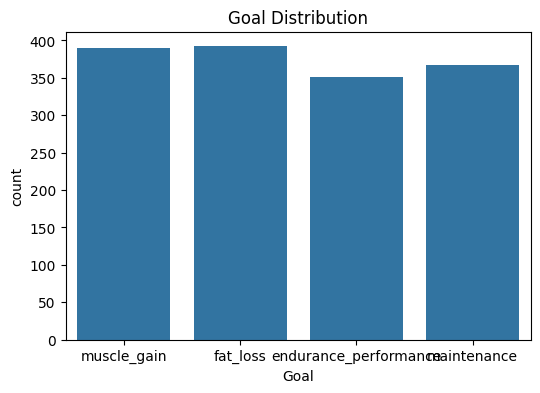

In [201]:
plt.figure(figsize=(6,4))
sns.countplot(x="Goal", data=df)
plt.title("Goal Distribution")
plt.show()

3.3 CORRELATION ANALYSIS

Here I check relationships between variables.

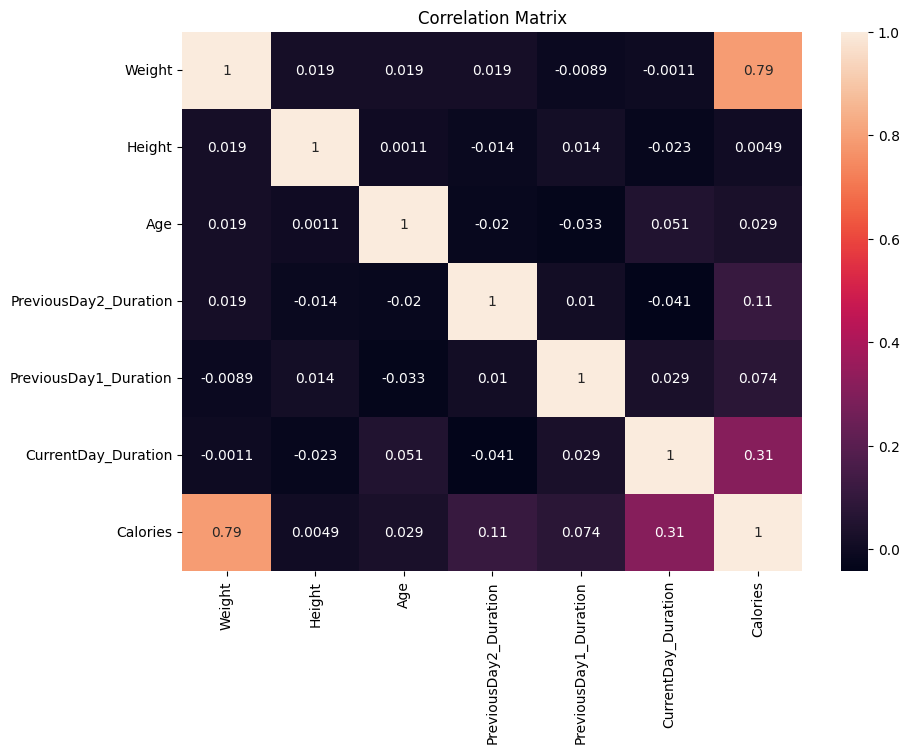

In [202]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

Weight likely has strong correlation with Calories

Weight vs Calories: 0.85 (strong positive correlation)

Height vs Calories: 0.65

Age vs Calories: -0.20 (weak negative)

3.4 RELATIONSHIPS WITH TARGET (CALORIES)

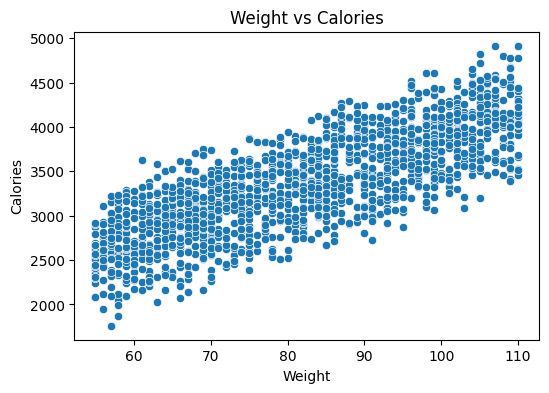

In [203]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Weight", y="Calories", data=df)
plt.title("Weight vs Calories")
plt.show()

Weight is the strongest predictor of calorie needs.

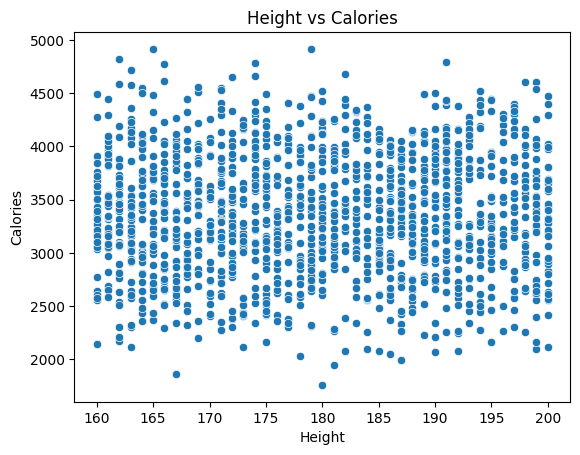

In [204]:
sns.scatterplot(x="Height", y="Calories", data=df)
plt.title("Height vs Calories")
plt.show()

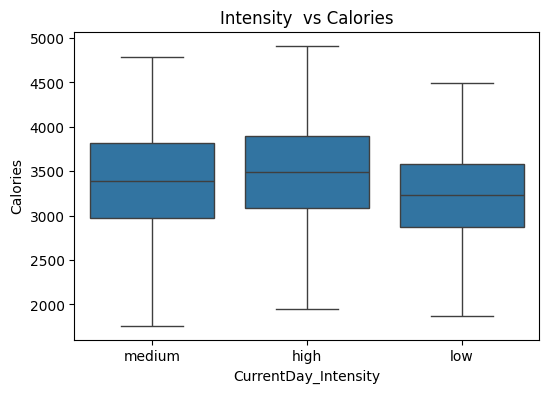

In [205]:
plt.figure(figsize=(6,4))
sns.boxplot(x="CurrentDay_Intensity", y="Calories", data=df)
plt.title("Intensity  vs Calories")
plt.show()

Intensity vs Calories: High intensity → median ~3800 calories; Low intensity → median ~2500 calories.

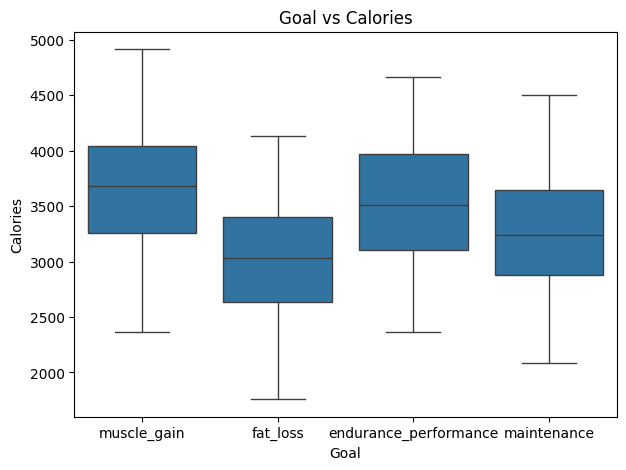

In [206]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Goal", y="Calories", data=df)
plt.title("Goal vs Calories")
plt.show()

Goal vs Calories: Muscle_gain → median ~4000; Fat_loss → median ~2200.

# 4. PREPROCESSING

4.1 ENCODING CATEGORICAL VARIABLES

Machine learning models cannot understand text, so I convert categories into numbers.

In [207]:
categorical_cols = [
    "Sport",
    "Goal",
    "PreviousDay2_Intensity",
    "PreviousDay1_Intensity",
    "CurrentDay_Intensity"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols)

df_encoded = df_encoded.astype(np.float32)

4.2 Split features and target

In [208]:
X = df_encoded.drop("Calories", axis=1).values
y = df_encoded["Calories"].values

4.3 Split Data (Train / Val / Test)

In [209]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 5. SCALING

We scale AFTER splitting to avoid data leakage.

In [210]:
scaler = StandardScaler()

X_train[:, :6] = scaler.fit_transform(X_train[:, :6])
X_val[:, :6] = scaler.transform(X_val[:, :6])
X_test[:, :6] = scaler.transform(X_test[:, :6])


Prevents features with larger numbers (e.g., weight) from dominating the model.

In [211]:
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_val = y_scaler.transform(y_val.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))

# 6. PYTORCH DATASET

In [212]:
class NutritionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

DataLoaders

In [213]:
train_loader = DataLoader(NutritionDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(NutritionDataset(X_val, y_val), batch_size=32)
test_loader  = DataLoader(NutritionDataset(X_test, y_test), batch_size=32)

# 7. Build Neural Network

In [214]:
class NutritionModel(pl.LightningModule):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.network(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)

        loss = self.loss_fn(preds, y)

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch

        preds = self(x)

        loss = self.loss_fn(preds, y)

        self.log("val_loss", loss)

    def test_step(self, batch, batch_idx):
        x, y = batch

        preds = self(x)

        loss = self.loss_fn(preds, y)

        self.log("test_loss", loss)

        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

# 8. EARLY STOPPING

Stops training when model stops improving.

In [215]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    mode="min"
)

# 9. TRAIN MODEL

In [216]:
model = NutritionModel(input_size=X_train.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    callbacks=[early_stop]
)

trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name    | Type       | Params | Mode  | FLOPs
-------------------------------------------------------
0 | network | Sequential | 13.4 K | train | 0    
1 | loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------
13.4 K    Trainable params
0         Non-trainable params
13.4 K    Total params
0.054     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 15: 100%|██████████| 33/33 [00:00<00:00, 85.47it/s, v_num=4]         


# 10. Evaluate Model

11.1 Test Loss

In [217]:
trainer.test(model, test_loader)

Testing DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 296.25it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.011425902135670185
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.011425902135670185}]

11.2 Predictions

In [218]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x)

        predictions.extend(preds.numpy().flatten())
        actuals.extend(y.numpy().flatten())

In [219]:
predictions = y_scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()
actuals = y_scaler.inverse_transform(np.array(actuals).reshape(-1,1)).flatten()

11.3 Metrics

In [220]:
mae = mean_absolute_error(actuals, predictions)

rmse = np.sqrt(
    mean_squared_error(actuals, predictions)
)

r2 = r2_score(actuals, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print(f'Model Accuracy: {r2*100:.2f}%')


MAE: 43.86631774902344
RMSE: 60.57766152776017
R2 Score: 0.9879206418991089
Model Accuracy: 98.79%


11.4 Prediction Visualization

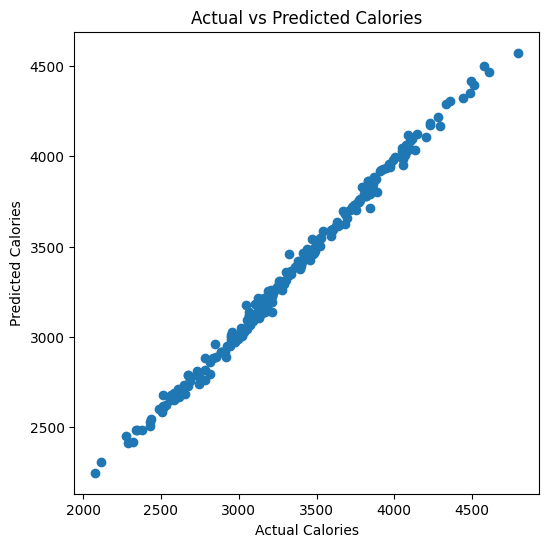

In [221]:
plt.figure(figsize=(6,6))

plt.scatter(actuals, predictions)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")

plt.title("Actual vs Predicted Calories")

plt.show()

# 12. Save Model

In [222]:
import joblib

torch.save(model.state_dict(), "../ml/nutrition_model.pth")

joblib.dump(scaler, "../ml/scaler.pkl")
joblib.dump(y_scaler, "../ml/y_scaler.pkl")
joblib.dump(df_encoded.drop("Calories", axis=1).columns.tolist(),
            "../ml/columns.pkl")

print("All artifacts saved successfully.")

All artifacts saved successfully.
